# RGM Copilot — Phase 1: Synthetic Data Generation & EDA

**Project goal:** An end-to-end FMCG Revenue Growth Management analytics copilot — demand forecasting, stockout-risk classification, and a GenAI assistant that answers business questions grounded in real model outputs.

This notebook covers:
1. Generating a realistic synthetic FMCG distribution dataset (regions × channels × SKUs × 2 years daily)
2. Exploratory data analysis to validate the data tells a sensible business story
3. Saving the clean dataset for the modeling notebooks (forecasting, classification, GenAI layer)

> Note: This dataset is **synthetic**, built to mirror realistic FMCG distribution patterns (seasonality, promotions, regional variation, supply constraints). No real company data is used.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
pd.set_option("display.max_columns", None)

## 2. Define business dimensions

Regions, channels, and SKUs — each with parameters that drive realistic demand patterns
(market size, channel behavior, seasonality sensitivity, lead times).

In [2]:
regions = [
    {"region": "Greater Cairo", "size_factor": 1.4},
    {"region": "Alexandria & North Coast", "size_factor": 1.1},
    {"region": "Delta Region", "size_factor": 1.0},
    {"region": "Upper Egypt", "size_factor": 0.8},
    {"region": "Suez Canal Zone", "size_factor": 0.7},
]

channels = [
    {"channel": "Modern Trade", "size_factor": 1.3, "weekend_boost": 1.25},
    {"channel": "Traditional Trade", "size_factor": 1.5, "weekend_boost": 1.05},
    {"channel": "HoReCa", "size_factor": 0.9, "weekend_boost": 1.6},
    {"channel": "E-Commerce", "size_factor": 0.5, "weekend_boost": 0.95},
]

skus = [
    {"sku": "Cola Regular 330ml", "base_price": 12.0, "popularity": 1.6, "summer_sensitivity": 1.3, "lead_time_days": 3},
    {"sku": "Cola Zero 330ml",    "base_price": 12.5, "popularity": 1.0, "summer_sensitivity": 1.2, "lead_time_days": 3},
    {"sku": "Lemon Soda 330ml",   "base_price": 11.0, "popularity": 0.8, "summer_sensitivity": 1.4, "lead_time_days": 4},
    {"sku": "Orange Soda 330ml",  "base_price": 11.0, "popularity": 0.9, "summer_sensitivity": 1.3, "lead_time_days": 4},
    {"sku": "Sparkling Water 500ml", "base_price": 9.0, "popularity": 1.1, "summer_sensitivity": 1.5, "lead_time_days": 2},
    {"sku": "Iced Tea 500ml",     "base_price": 14.0, "popularity": 0.7, "summer_sensitivity": 1.6, "lead_time_days": 5},
    {"sku": "Energy Drink 250ml", "base_price": 20.0, "popularity": 0.6, "summer_sensitivity": 1.1, "lead_time_days": 6},
    {"sku": "Juice 1L",           "base_price": 28.0, "popularity": 0.5, "summer_sensitivity": 0.9, "lead_time_days": 5},
]

dates = pd.date_range("2023-01-01", "2024-12-30", freq="D")
print(f"{len(regions)} regions x {len(channels)} channels x {len(skus)} SKUs x {len(dates)} days "
      f"= {len(regions)*len(channels)*len(skus)*len(dates):,} rows")

5 regions x 4 channels x 8 SKUs x 730 days = 116,800 rows


## 3. Generate daily sales, promotions, and inventory simulation

For each region/channel/SKU combination, simulate:
- **Trend**: slow underlying growth/decline
- **Yearly seasonality**: summer demand peaks (cold beverages), SKU-specific sensitivity
- **Weekly seasonality**: weekend boosts (varies by channel — HoReCa spikes hardest)
- **Promotions**: ~6% of days, with price discount + demand uplift
- **Inventory & supply**: simple reorder-point policy with lead times, producing realistic stockout events when demand exceeds on-hand stock

In [3]:
rows = []
for r in regions:
    for c in channels:
        for s in skus:
            base = 40 * r["size_factor"] * c["size_factor"] * s["popularity"]
            trend_rate = rng.normal(0.00015, 0.0001)
            promo_days = rng.random(len(dates)) < 0.06

            # initial inventory & reorder policy (tuned for a realistic but
            # meaningful stockout rate, ~4-6%)
            on_hand = base * rng.uniform(5, 9)
            reorder_point = base * s["lead_time_days"] * 0.9
            reorder_qty = base * 7
            pending_orders = []

            for i, d in enumerate(dates):
                doy = d.dayofyear
                dow = d.dayofweek

                seasonality = 1 + 0.35 * s["summer_sensitivity"] * np.sin(2 * np.pi * (doy - 100) / 365)
                weekend = c["weekend_boost"] if dow >= 4 else 1.0
                trend = (1 + trend_rate) ** i

                promo_uplift = 1.0
                price = s["base_price"] * (1 + rng.normal(0, 0.01))
                if promo_days[i]:
                    promo_uplift = rng.uniform(1.3, 1.8)
                    price = price * rng.uniform(0.75, 0.9)

                noise = rng.normal(1, 0.12)
                demand = max(0, base * seasonality * weekend * trend * promo_uplift * noise)
                demand = int(round(demand))

                arrived = [q for (arrive_i, q) in pending_orders if arrive_i == i]
                on_hand += sum(arrived)
                pending_orders = [(ai, q) for (ai, q) in pending_orders if ai != i]

                units_sold = min(demand, on_hand)
                stockout = 1 if demand > on_hand else 0
                on_hand -= units_sold

                if on_hand <= reorder_point:
                    pending_orders.append((i + s["lead_time_days"], reorder_qty))

                revenue = units_sold * price

                rows.append((
                    d, r["region"], c["channel"], s["sku"], price,
                    promo_days[i], demand, units_sold, stockout,
                    round(on_hand, 1), revenue, s["lead_time_days"]
                ))

df = pd.DataFrame(rows, columns=[
    "date", "region", "channel", "sku", "unit_price", "on_promo",
    "demand_units", "units_sold", "stockout_flag", "on_hand_after",
    "revenue", "lead_time_days"
])

print(df.shape)
df.head()

(116800, 12)


,date,region,channel,sku,unit_price,on_promo,demand_units,units_sold,stockout_flag,on_hand_after,revenue,lead_time_days
0,2023-01-01,Greater Cairo,Modern Trade,Cola Regular 330ml,11.876302,False,79,79.0,0,527.1,938.227886,3
1,2023-01-02,Greater Cairo,Modern Trade,Cola Regular 330ml,12.125901,False,56,56.0,0,471.1,679.050447,3
2,2023-01-03,Greater Cairo,Modern Trade,Cola Regular 330ml,11.890731,False,68,68.0,0,403.1,808.569709,3
3,2023-01-04,Greater Cairo,Modern Trade,Cola Regular 330ml,11.973416,False,69,69.0,0,334.1,826.165681,3
4,2023-01-05,Greater Cairo,Modern Trade,Cola Regular 330ml,11.998362,False,69,69.0,0,265.1,827.887005,3


## 4. Sanity checks

In [4]:
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Stockout rate: {:.2%}".format(df['stockout_flag'].mean()))
print("Promo day rate: {:.2%}".format(df['on_promo'].mean()))
print("\nMissing values:\n", df.isna().sum())
df.describe()

Date range: 2023-01-01 to 2024-12-30
Stockout rate: 4.61%
Promo day rate: 5.93%

Missing values:
 date              0
region            0
channel           0
sku               0
unit_price        0
on_promo          0
demand_units      0
units_sold        0
stockout_flag     0
on_hand_after     0
revenue           0
lead_time_days    0
dtype: int64


,date,unit_price,demand_units,units_sold,stockout_flag,on_hand_after,revenue,lead_time_days
count,116800,116800.000000,116800.000000,116800.000000,116800.000000,116800.000000,116800.000000,116800.00000
mean,2023-12-31 12:00:00,14.535784,45.084580,43.255818,0.046139,407.682369,568.567964,4.00000
min,2023-01-01 00:00:00,6.663376,3.000000,0.000000,0.000000,0.000000,0.000000,2.00000
25%,2023-07-02 00:00:00,10.973005,21.000000,20.000000,0.000000,146.600000,275.013237,3.00000
50%,2023-12-31 12:00:00,12.144559,36.000000,34.000000,0.000000,316.400000,476.874249,4.00000
75%,2024-07-01 00:00:00,14.558750,59.000000,57.000000,0.000000,579.000000,766.577346,5.00000
max,2024-12-30 00:00:00,29.310363,428.000000,428.000000,1.000000,2787.600000,4187.523118,6.00000
std,NaN,5.873172,34.214661,33.784308,0.209786,352.027612,400.281187,1.22475


## 5. EDA — does the data tell a sensible business story?

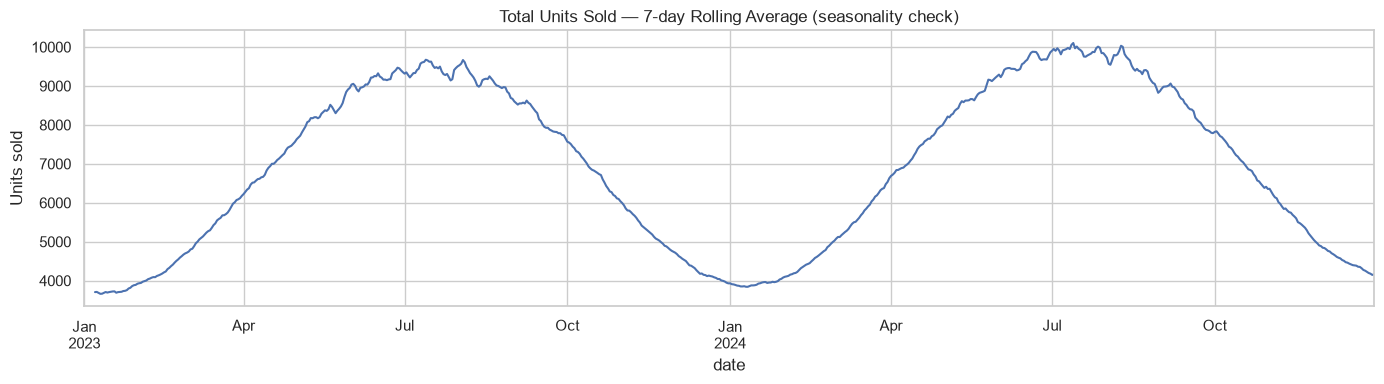

In [5]:
daily_total = df.groupby("date")["units_sold"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
daily_total.rolling(7).mean().plot(ax=ax)
ax.set_title("Total Units Sold — 7-day Rolling Average (seasonality check)")
ax.set_ylabel("Units sold")
plt.tight_layout()
plt.show()

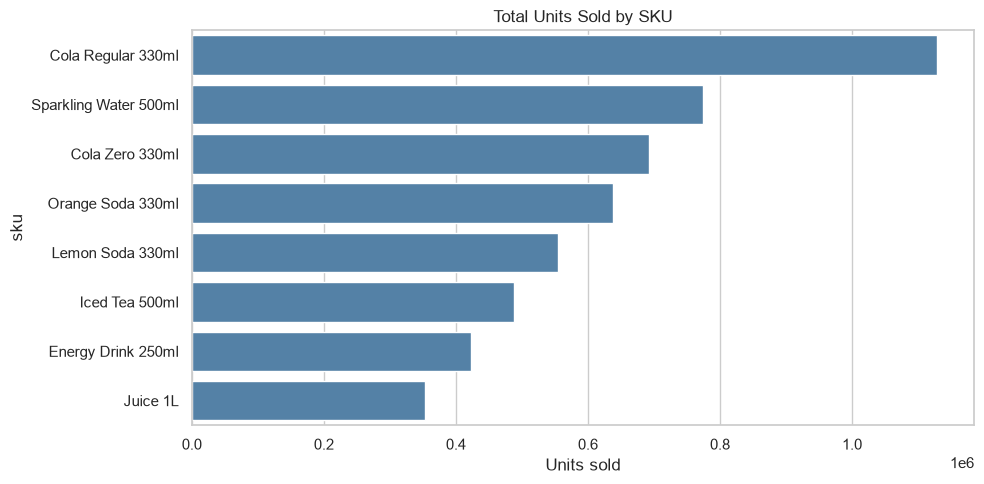

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sku_totals = df.groupby("sku")["units_sold"].sum().sort_values(ascending=False)
sns.barplot(x=sku_totals.values, y=sku_totals.index, ax=ax, color="steelblue")
ax.set_title("Total Units Sold by SKU")
ax.set_xlabel("Units sold")
plt.tight_layout()
plt.show()

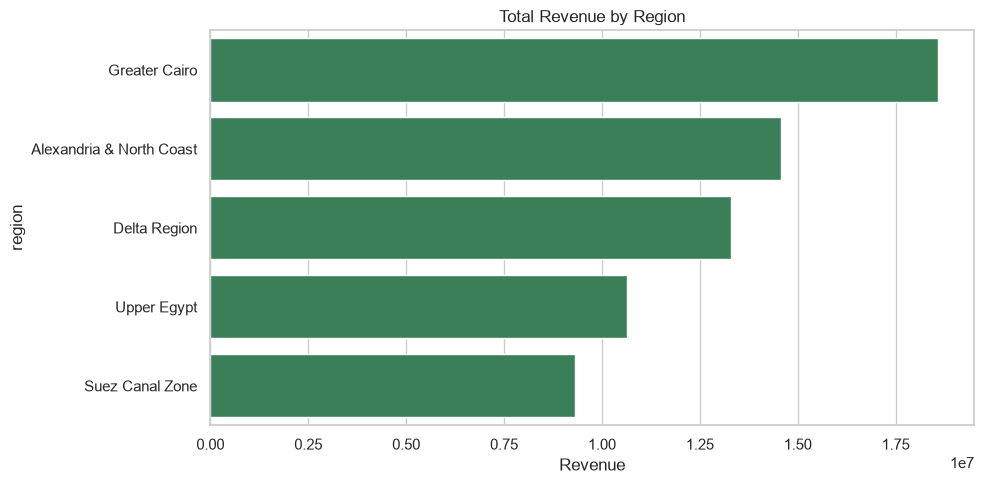

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
region_totals = df.groupby("region")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=region_totals.values, y=region_totals.index, ax=ax, color="seagreen")
ax.set_title("Total Revenue by Region")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()

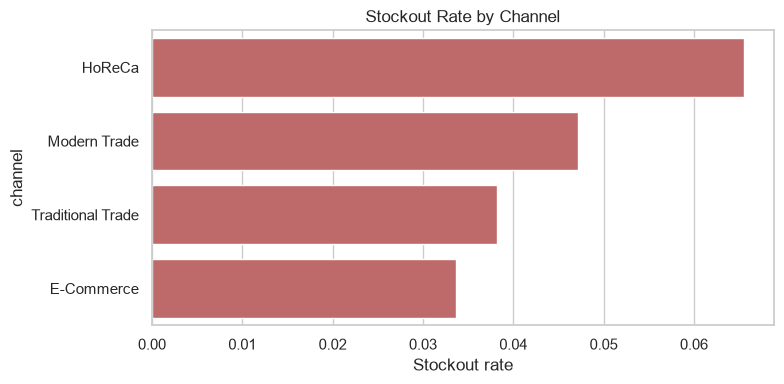

In [8]:
stockout_by_channel = df.groupby("channel")["stockout_flag"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=stockout_by_channel.values, y=stockout_by_channel.index, ax=ax, color="indianred")
ax.set_title("Stockout Rate by Channel")
ax.set_xlabel("Stockout rate")
plt.tight_layout()
plt.show()

In [9]:
promo_effect = df.groupby("on_promo")["units_sold"].mean()
print("Average units sold — no promo vs promo:")
print(promo_effect)
print(f"\nPromo uplift: {(promo_effect[True]/promo_effect[False] - 1):.1%}")

Average units sold — no promo vs promo:
on_promo
False    41.888654
True     64.951154
Name: units_sold, dtype: float64

Promo uplift: 55.1%


## 6. Save the dataset

This file feeds into the next notebooks:
- `02_demand_forecasting.ipynb`
- `03_stockout_classification.ipynb`
- `04_genai_rag_layer.ipynb`

In [10]:
df.to_csv("../data/rgm_copilot_dataset.csv", index=False)
print("Saved ../data/rgm_copilot_dataset.csv —", df.shape)

Saved ../data/rgm_copilot_dataset.csv — (116800, 12)
